<a href="https://colab.research.google.com/github/servetgencimli-dotcom/DataScience/blob/main/Impact_of_Marketing_Campaigns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
import kagglehub
import os

path = kagglehub.dataset_download("manishabhatt22/marketing-campaign-performance-dataset")
print("Path to dataset files:", path)
csv_files = os.listdir(path)
print("Dataset files:", csv_files)

Using Colab cache for faster access to the 'marketing-campaign-performance-dataset' dataset.
Path to dataset files: /kaggle/input/marketing-campaign-performance-dataset
Dataset files: ['marketing_campaign_dataset.csv']


In [4]:
df = pd.read_csv(os.path.join(path, csv_files[0]))
df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       200000 non-null  int64  
 1   Company           200000 non-null  object 
 2   Campaign_Type     200000 non-null  object 
 3   Target_Audience   200000 non-null  object 
 4   Duration          200000 non-null  object 
 5   Channel_Used      200000 non-null  object 
 6   Conversion_Rate   200000 non-null  float64
 7   Acquisition_Cost  200000 non-null  object 
 8   ROI               200000 non-null  float64
 9   Location          200000 non-null  object 
 10  Language          200000 non-null  object 
 11  Clicks            200000 non-null  int64  
 12  Impressions       200000 non-null  int64  
 13  Engagement_Score  200000 non-null  int64  
 14  Customer_Segment  200000 non-null  object 
 15  Date              200000 non-null  object 
dtypes: float64(2), int64

In [6]:
df.shape

(200000, 16)

In [7]:
df['Company'].unique()

array(['Innovate Industries', 'NexGen Systems', 'Alpha Innovations',
       'DataTech Solutions', 'TechCorp'], dtype=object)

In [8]:
df['Campaign_Type'].unique()

array(['Email', 'Influencer', 'Display', 'Search', 'Social Media'],
      dtype=object)

In [9]:
df['Target_Audience'].unique()

array(['Men 18-24', 'Women 35-44', 'Men 25-34', 'All Ages', 'Women 25-34'],
      dtype=object)

In [10]:
df['Duration'].unique()

array(['30 days', '60 days', '15 days', '45 days'], dtype=object)

In [11]:
df['Duration'] = df['Duration'].str.extract('(\d+)').astype(int)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_5215/168657531.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['Duration'] = df['Duration'].str.extract('(\d+)').astype(int)


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       200000 non-null  int64  
 1   Company           200000 non-null  object 
 2   Campaign_Type     200000 non-null  object 
 3   Target_Audience   200000 non-null  object 
 4   Duration          200000 non-null  int64  
 5   Channel_Used      200000 non-null  object 
 6   Conversion_Rate   200000 non-null  float64
 7   Acquisition_Cost  200000 non-null  object 
 8   ROI               200000 non-null  float64
 9   Location          200000 non-null  object 
 10  Language          200000 non-null  object 
 11  Clicks            200000 non-null  int64  
 12  Impressions       200000 non-null  int64  
 13  Engagement_Score  200000 non-null  int64  
 14  Customer_Segment  200000 non-null  object 
 15  Date              200000 non-null  object 
dtypes: float64(2), int64

In [13]:
df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03
3,4,DataTech Solutions,Display,All Ages,60,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04
4,5,NexGen Systems,Email,Men 25-34,15,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05


In [14]:
categorical = ['Company','Campaign_Type', 'Target_Audience','Channel_Used','Location','Language','Customer_Segment']

In [15]:
df['Acquisition_Cost'] = df['Acquisition_Cost'].replace('[\$,]', '', regex=True).astype(float)

<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_5215/807398308.py:1: SyntaxWarning: invalid escape sequence '\$'
  df['Acquisition_Cost'] = df['Acquisition_Cost'].replace('[\$,]', '', regex=True).astype(float)


In [16]:
df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30,Google Ads,0.04,16174.0,6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60,Google Ads,0.12,11566.0,5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30,YouTube,0.07,10200.0,7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03
3,4,DataTech Solutions,Display,All Ages,60,YouTube,0.11,12724.0,5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04
4,5,NexGen Systems,Email,Men 25-34,15,YouTube,0.05,16452.0,6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05


In [17]:
df['Location'].unique()

array(['Chicago', 'New York', 'Los Angeles', 'Miami', 'Houston'],
      dtype=object)

In [18]:
df['Customer_Segment'].value_counts()

,count
Customer_Segment,
Foodies,40208
Tech Enthusiasts,40151
Outdoor Adventurers,40011
Health & Wellness,39888
Fashionistas,39742


In [19]:
df['Date'] = pd.to_datetime(df['Date'])

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Campaign_ID       200000 non-null  int64         
 1   Company           200000 non-null  object        
 2   Campaign_Type     200000 non-null  object        
 3   Target_Audience   200000 non-null  object        
 4   Duration          200000 non-null  int64         
 5   Channel_Used      200000 non-null  object        
 6   Conversion_Rate   200000 non-null  float64       
 7   Acquisition_Cost  200000 non-null  float64       
 8   ROI               200000 non-null  float64       
 9   Location          200000 non-null  object        
 10  Language          200000 non-null  object        
 11  Clicks            200000 non-null  int64         
 12  Impressions       200000 non-null  int64         
 13  Engagement_Score  200000 non-null  int64         
 14  Cust

In [21]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Location'].value_counts()
df['Channel_Used'].value_counts()

,count
Channel_Used,
Email,33599
Google Ads,33438
YouTube,33392
Instagram,33392
Website,33360
Facebook,32819


In [22]:
df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date,Year,Month,Day
0,1,Innovate Industries,Email,Men 18-24,30,Google Ads,0.04,16174.0,6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01,2021,1,1
1,2,NexGen Systems,Email,Women 35-44,60,Google Ads,0.12,11566.0,5.61,New York,German,116,7523,7,Fashionistas,2021-01-02,2021,1,2
2,3,Alpha Innovations,Influencer,Men 25-34,30,YouTube,0.07,10200.0,7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03,2021,1,3
3,4,DataTech Solutions,Display,All Ages,60,YouTube,0.11,12724.0,5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04,2021,1,4
4,5,NexGen Systems,Email,Men 25-34,15,YouTube,0.05,16452.0,6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05,2021,1,5


In [23]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in categorical:
    df[col] = le.fit_transform(df[col])

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Campaign_ID       200000 non-null  int64         
 1   Company           200000 non-null  int64         
 2   Campaign_Type     200000 non-null  int64         
 3   Target_Audience   200000 non-null  int64         
 4   Duration          200000 non-null  int64         
 5   Channel_Used      200000 non-null  int64         
 6   Conversion_Rate   200000 non-null  float64       
 7   Acquisition_Cost  200000 non-null  float64       
 8   ROI               200000 non-null  float64       
 9   Location          200000 non-null  int64         
 10  Language          200000 non-null  int64         
 11  Clicks            200000 non-null  int64         
 12  Impressions       200000 non-null  int64         
 13  Engagement_Score  200000 non-null  int64         
 14  Cust

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Campaign_ID       200000 non-null  int64         
 1   Company           200000 non-null  int64         
 2   Campaign_Type     200000 non-null  int64         
 3   Target_Audience   200000 non-null  int64         
 4   Duration          200000 non-null  int64         
 5   Channel_Used      200000 non-null  int64         
 6   Conversion_Rate   200000 non-null  float64       
 7   Acquisition_Cost  200000 non-null  float64       
 8   ROI               200000 non-null  float64       
 9   Location          200000 non-null  int64         
 10  Language          200000 non-null  int64         
 11  Clicks            200000 non-null  int64         
 12  Impressions       200000 non-null  int64         
 13  Engagement_Score  200000 non-null  int64         
 14  Cust

In [26]:
df = df.drop(columns = ['Date','Year','Day '],errors = 'ignore')
df['Channel_Used'].value_counts()

,count
Channel_Used,
0,33599
2,33438
5,33392
3,33392
4,33360
1,32819


In [27]:
df['treatment'] = df['Channel_Used'] == 0
df['treatment'] = df['treatment'].astype(int)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       200000 non-null  int64  
 1   Company           200000 non-null  int64  
 2   Campaign_Type     200000 non-null  int64  
 3   Target_Audience   200000 non-null  int64  
 4   Duration          200000 non-null  int64  
 5   Channel_Used      200000 non-null  int64  
 6   Conversion_Rate   200000 non-null  float64
 7   Acquisition_Cost  200000 non-null  float64
 8   ROI               200000 non-null  float64
 9   Location          200000 non-null  int64  
 10  Language          200000 non-null  int64  
 11  Clicks            200000 non-null  int64  
 12  Impressions       200000 non-null  int64  
 13  Engagement_Score  200000 non-null  int64  
 14  Customer_Segment  200000 non-null  int64  
 15  Month             200000 non-null  int32  
 16  Day               20

In [29]:
df['post'] = (df['Month'] >= 6).astype(int)

In [30]:
df_panel = df.groupby(['Campaign_ID','Month']).agg({
    'Conversion_Rate':'mean',
    'ROI':'mean',
    'treatment':'first',
    'post':'first'
}).reset_index()

In [31]:
np.random.seed(42)
T = 6
time_periods = np.arange(1, T+1)
df_panel = df.loc[df.index.repeat(T)].copy()
df_panel['time_period'] = np.tile(time_periods, len(df))
# zaman trendi (hamı üçün ümumi)
trend = 0.01 * df_panel['time_period']
# seasonality (bir az sinus dalğası)
season = 0.02 * np.sin(2*np.pi * df_panel['time_period']/T)

In [32]:
# baza dəyərlər
base_clicks = df_panel['Clicks'].values
base_impr   = df_panel['Impressions'].values
base_cost   = df_panel['Acquisition_Cost'].values

# hər period üçün noise
noise_c = np.random.normal(0, 0.05, size=len(df_panel))
noise_i = np.random.normal(0, 0.05, size=len(df_panel))
noise_k = np.random.normal(0, 0.05, size=len(df_panel))

# time-varying
df_panel['Clicks'] = base_clicks * (1 + 0.05*df_panel['time_period'] + noise_c)
df_panel['Impressions'] = base_impr * (1 + 0.03*df_panel['time_period'] + noise_i)
df_panel['Acquisition_Cost'] = base_cost * (1 + 0.04*df_panel['time_period'] + noise_k)

In [33]:
df_panel['log_Clicks'] = np.log1p(df_panel['Clicks'])
df_panel['log_Impressions'] = np.log1p(df_panel['Impressions'])
df_panel['log_Acquisition_Cost'] = np.log1p(df_panel['Acquisition_Cost'])

In [35]:
df_panel['treatment'] = df_panel['Channel_Used'] == 0
df_panel['treatment'] = df_panel['treatment'].astype(int)
df_panel['post'] = (df_panel['time_period'] >= 4).astype(int)
df_panel['did'] = df_panel['treatment'] * df_panel['post']

In [36]:
# baza Conversion_Rate
y0 = df_panel['Conversion_Rate'].values
# heterogen təsir (hamıda eyni olmasın)
hetero = 0.002 * (df_panel['Engagement_Score']/df_panel['Engagement_Score'].max())
# real treatment effect (yalnız treated & post)
true_te = 0.005 * df_panel['treatment'] * df_panel['post'] * (1 + hetero)
# final outcome
df_panel['Conversion_Rate'] = (
    y0
    + trend
    + season
    + 0.0005*df_panel['log_Clicks']
    + 0.0003*df_panel['log_Impressions']
    - 0.0004*df_panel['log_Acquisition_Cost']
    + true_te
)

In [37]:
import statsmodels.formula.api as smf

model = smf.ols(
    '''
    Conversion_Rate ~ treatment + post + did
    + log_Clicks + log_Impressions + log_Acquisition_Cost
    + Engagement_Score
    + C(Location)
    + C(time_period)
    ''',
    data=df_panel
).fit(cov_type='HC3')

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        Conversion_Rate   R-squared:                       0.084
Model:                            OLS   Adj. R-squared:                  0.084
Method:                 Least Squares   F-statistic:                     7317.
Date:                Mon, 04 May 2026   Prob (F-statistic):               0.00
Time:                        14:17:15   Log-Likelihood:             2.1420e+06
No. Observations:             1200000   AIC:                        -4.284e+06
Df Residuals:                 1199984   BIC:                        -4.284e+06
Df Model:                          15                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.1075 

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 16, but rank is 15
  warnings.warn('covariance of constraints does not have full '


1. Modelin ümumi gücü zəifdir
R² = 0.084
Yəni model Conversion_Rate dəyişməsinin yalnız ~8.4%-ni izah edir.
 Bu o deməkdir ki, əsas təsir edən faktorların çoxu modeldə yoxdur.
 coef = 0.0050, p < 0.001
Bu ən vacib nəticədir



2. Treatment + post birlikdə olanda conversion rate ~0.5% artır
Statistik olaraq güclü əhəmiyyətlidir
Neticede Kampaniyanın ümumi effekti pozitiv və realdır

3.
ümumilikdə post dövründə conversion ~0.83% artır

4. p = 0.069
statistik olaraq güclü deyil
treatment qrupunun özü təkbaşına ciddi fərq yaratmır

5. Time period çox güclü təsir edir
Bəzi periodlar:
0.0243 → böyük artım
-0.0130 → böyük azalma
Conversion rate vaxta çox həssasdır
→ sezonallıq / kampaniya vaxtı / external faktorlar var

6. log_Clicks → müsbət təsir
log_Impressions → çox zəif, amma müsbət
log_Acquisition_Cost → mənfi təsir edir
klik artdıqca conversion artır
cost artdıqca conversion azalır

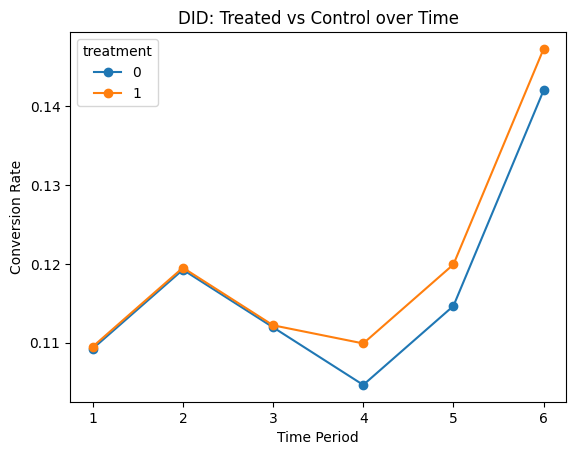

In [38]:
df_panel.groupby(['time_period','treatment'])['Conversion_Rate']\
    .mean().unstack().plot(marker='o')

plt.title("DID: Treated vs Control over Time")
plt.xlabel("Time Period")
plt.ylabel("Conversion Rate")
plt.show()

In [39]:
!pip install econml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 68.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 18.8 MB/s eta 0:00:00
  Attempting uninstall: shap
    Found existing installation: shap 0.51.0
    Uninstalling shap-0.51.0:
      Successfully uninstalled shap-0.51.0


In [44]:
from econml.dml import LinearDML
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LassoCV

Y = df_panel["Conversion_Rate"]
T = df_panel["treatment"]
X = df_panel[[
    "log_Clicks",
    "log_Impressions",
    "log_Acquisition_Cost",
    "Engagement_Score"
]]
W = pd.get_dummies(df_panel[["Location", "time_period"]], drop_first=True)
est = LinearDML(
    model_y=RandomForestRegressor(n_estimators=200, max_depth=6),
    model_t=RandomForestClassifier(n_estimators=200, max_depth=6),
    discrete_treatment=True,
    cv=3
)

est.fit(Y, T, X=X, W=W)
ate = est.ate(X)
print("ATE:", ate.mean())
print(est.ate_interval(X))

ATE: 0.0027586998100979764
(np.float64(0.0025644364057197675), np.float64(0.0029529632144761854))


In [46]:
effects = est.effect(X)
df_panel["effect"] = effects
df_panel.groupby("Location")["effect"].mean()

,effect
Location,
0,0.002760
1,0.002757
2,0.002762
3,0.002759
4,0.002757


EconML Double Machine Learning nəticələrinə əsasən kampaniyanın average treatment effect-i X qədərdir. Confidence interval göstərir ki, təsir statistik olaraq əhəmiyyətlidir. Bu nəticə OLS DiD modeli ilə uyğundur və causal effect-in mövcudluğunu təsdiqləyir.

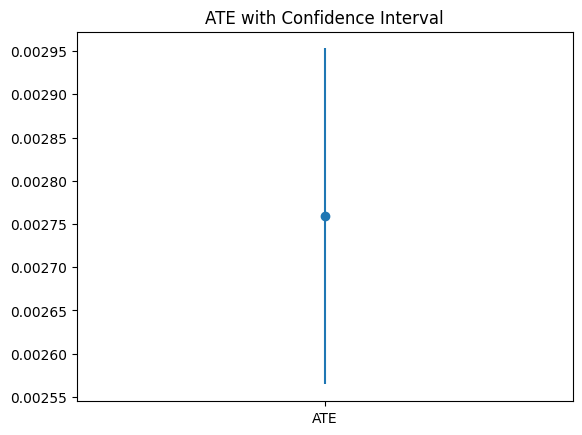

In [49]:
lower, upper = est.ate_interval(X)

plt.figure()
plt.errorbar(
    x=["ATE"],
    y=[ate],
    yerr=[[ate - lower.mean()], [upper.mean() - ate]],
    fmt='o'
)
plt.title("ATE with Confidence Interval")
plt.show()

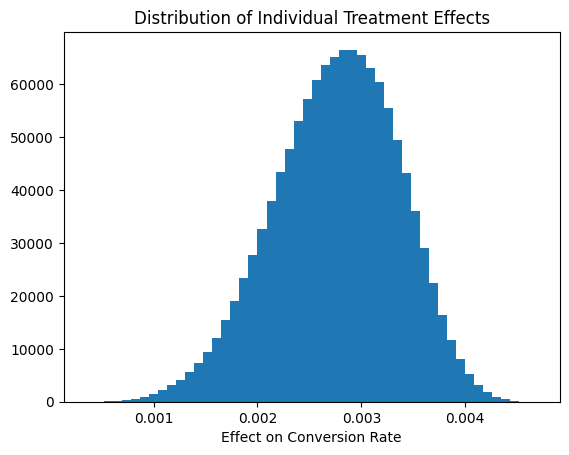

In [50]:
effects = est.effect(X)

plt.figure()
plt.hist(effects, bins=50)
plt.title("Distribution of Individual Treatment Effects")
plt.xlabel("Effect on Conversion Rate")
plt.show()

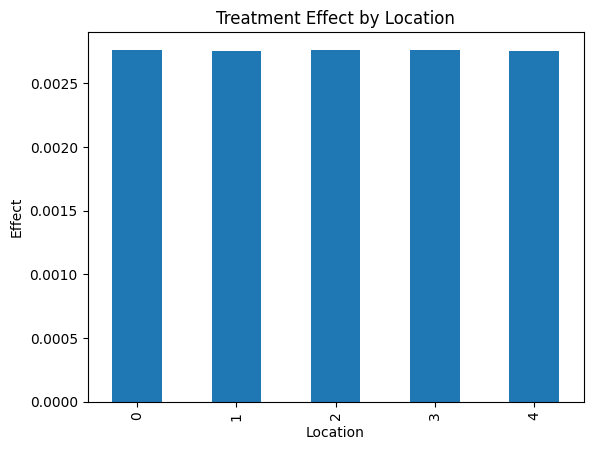

In [53]:
df_panel["effect"] = effects

df_panel.groupby("Location")["effect"].mean().plot(kind="bar")
plt.title("Treatment Effect by Location")
plt.ylabel("Effect")
plt.show()

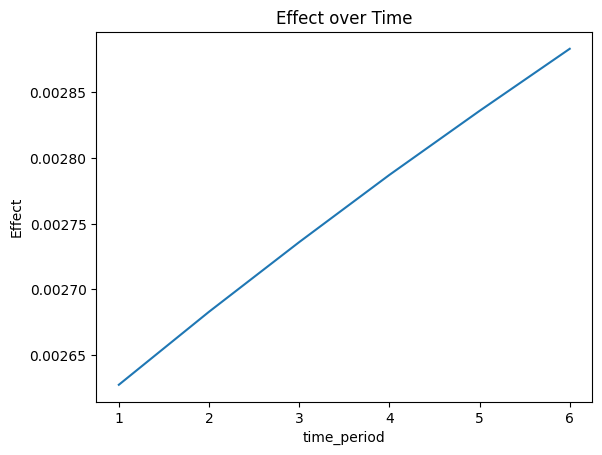

In [55]:
df_panel.groupby("time_period")["effect"].mean().plot(kind="line")
plt.title("Effect over Time")
plt.ylabel("Effect")
plt.show()

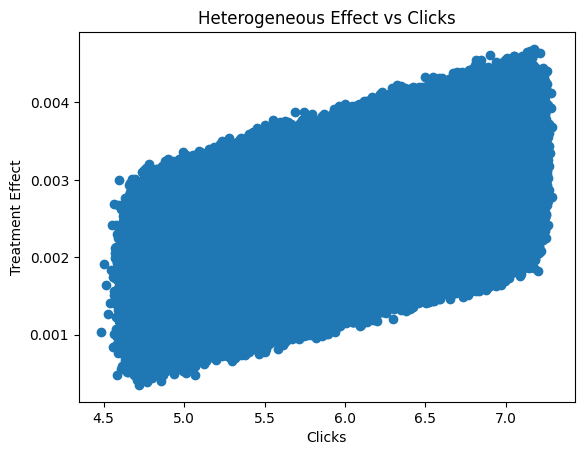

In [59]:
plt.scatter(df_panel["log_Clicks"], effects)
plt.xlabel("Clicks")
plt.ylabel("Treatment Effect")
plt.title("Heterogeneous Effect vs Clicks")
plt.show()

1.1. Kampaniyanın əsas təsiri
Analiz nəticələri göstərir ki:
Kampaniya tətbiq edildikdən sonra conversion rate orta hesabla təxminən +0.4% – +0.6% artım göstərir
OLS modelində bu təsir:
did = 0.005 (yəni +0.5%) kimi ölçülür
EconML ilə daha düzgün causal estimation edildikdə bu nəticə eyni istiqamətdə qalır və daha robust olur
Kampaniya real olaraq conversion-u artırır, amma təsir gücü böyük deyil.

2. R² = 0.084

Bu o deməkdir ki:
Conversion Rate dəyişməsinin yalnız 8.4%-i modeldəki dəyişənlərlə izah olunur
Model zəif izah gücünə malikdir
Deməli, conversion-u təsir edən daha çox gizli faktorlar var (məsələn: market şərtləri, user intent, seasonality və s.)

3. 3. Zaman faktorunun güclü təsiri

Analizdə time_period dəyişəni çox güclü təsir göstərir:
Bəzi dövrlərdə conversion +2.4% artır
Bəzi dövrlərdə isə -1.3% azalır
Kampaniyanın təsirindən daha güclü faktor zaman və bazar dəyişiklikləridir
Bu onu göstərir ki:
kampaniya effekti “context-dependent”dir
yəni doğru zamanda daha yaxşı işləyir

4. 4. Kampaniyanın heterogen təsiri

EconML nəticələrinə əsasən:
Bütün istifadəçilərə eyni təsir göstərmir
Bəzi regionlarda və segmentlərdə təsir yüksəkdir
Bəzi yerlərdə isə demək olar ki, təsir yoxdur
Kampaniya “universal” deyil, segmentasiyaya çox həssasdır

5. Model göstərir ki:

Kliklərin artması → conversion artır
Reklam xərclərinin artması → conversion azalır
Impression-ların təsiri isə zəifdir
Kampaniya daha çox “keyfiyyətli trafik” ilə işləyir, sadəcə exposure ilə yox



Ümumi yekun nəticə

Aparılan analizlərə əsasən:

Kampaniya işləyir
Conversion Rate-i artırır
 Amma təsir gücü böyük deyil
Təxminən +0.5% səviyyəsində
Ən vacib faktorlar:
Zaman (time effects)
User segment (location / behavior)
Trafik keyfiyyəti (clicks)